# Análisis Histórico de Acciones de Netflix (NFLX)

Este proyecto tiene como objetivo analizar el comportamiento histórico de las acciones de Netflix (NFLX) utilizando técnicas de análisis exploratorio de datos (EDA), visualización, análisis temporal y modelos predictivos básicos.

* Objetivo:
Analizar el comportamiento histórico de las acciones de Netflix e identificar patrones, tendencias y posibles predicciones futuras.

## Importar Librerias

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Carga de datos

In [39]:
# Carga del Dataset
df = pd.read_csv("../data/NFLX_stocks.csv")
# Verificacion de datos
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5803 entries, 0 to 5802
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       5802 non-null   object
 1   open       5803 non-null   object
 2   high       5803 non-null   object
 3   low        5803 non-null   object
 4   close      5803 non-null   object
 5   adj_close  5803 non-null   object
 6   volume     5803 non-null   object
dtypes: object(7)
memory usage: 317.5+ KB


In [40]:
df.head()

,date,open,high,low,close,adj_close,volume
0,NaN,NFLX,NFLX,NFLX,NFLX,NFLX,NFLX
1,2002-05-23,1.1564290523529053,1.2428569793701172,1.1457140445709229,1.1964290142059326,1.1964290142059326,104790000
2,2002-05-24,1.214285969734192,1.225000023841858,1.1971429586410522,1.2100000381469727,1.2100000381469727,11104800
3,2002-05-28,1.2135709524154663,1.2321430444717407,1.157142996788025,1.157142996788025,1.157142996788025,6609400
4,2002-05-29,1.1642860174179077,1.1642860174179077,1.0857139825820923,1.1035710573196411,1.1035710573196411,6757800


## Limpieza de datos

In [41]:
# Eliminar la primera fila incorrecta

df = df.iloc[1:].copy()

# Convertir fecha

df['date'] = pd.to_datetime(df['date'])

# Convertir columnas numéricas
numeric_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5802 entries, 1 to 5802
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       5802 non-null   datetime64[ns]
 1   open       5802 non-null   float64       
 2   high       5802 non-null   float64       
 3   low        5802 non-null   float64       
 4   close      5802 non-null   float64       
 5   adj_close  5802 non-null   float64       
 6   volume     5802 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 317.4 KB


In [42]:
df.head()

,date,open,high,low,close,adj_close,volume
1,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
2,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
3,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
4,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
5,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


In [43]:
df.isnull().sum()

date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

## Analisis Exploratorio

In [44]:
df.describe()

,date,open,high,low,close,adj_close,volume
count,5802,5802.000000,5802.000000,5802.000000,5802.000000,5802.000000,5.802000e+03
mean,2013-11-29 19:26:29.658738176,172.720291,175.297992,170.150462,172.807773,172.807773,1.515328e+07
min,2002-05-23 00:00:00,0.377857,0.410714,0.346429,0.372857,0.372857,2.856000e+05
25%,2008-02-27 06:00:00,4.308928,4.401786,4.225714,4.307143,4.307143,5.391400e+06
50%,2013-11-28 00:00:00,47.290001,47.903570,46.326427,47.187143,47.187143,9.374850e+06
75%,2019-09-04 18:00:00,318.120003,323.845001,312.787491,317.935005,317.935005,1.804652e+07
max,2025-06-12 00:00:00,1259.410034,1262.810059,1237.290039,1250.520020,1250.520020,3.234140e+08
std,NaN,234.674992,237.933952,231.550122,234.885388,234.885388,1.837246e+07


### Evaluación del precio

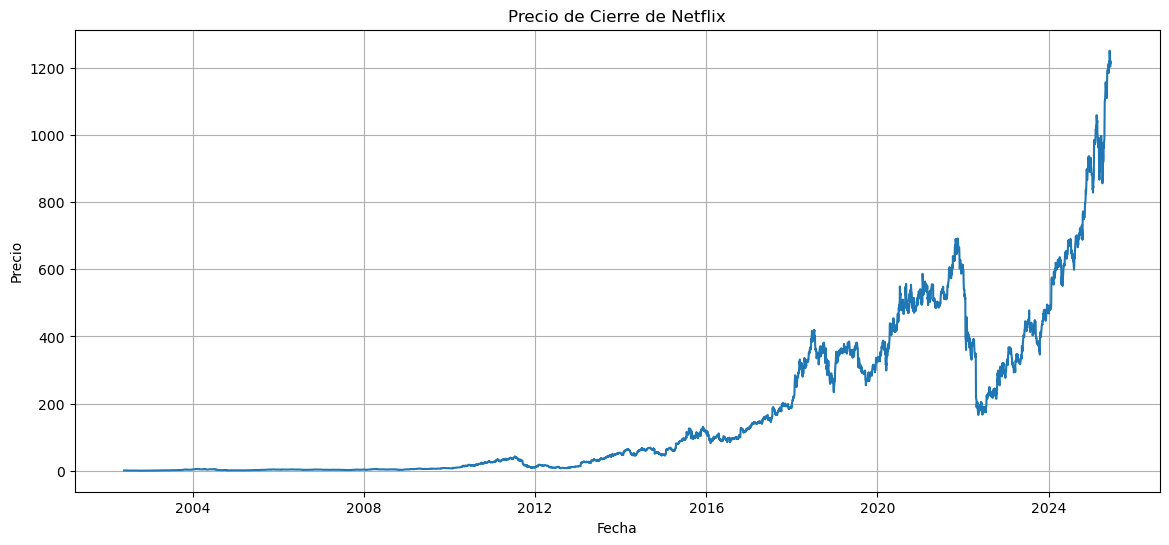

In [45]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['close'])
plt.title('Precio de Cierre de Netflix')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

### Volumen de operaciones

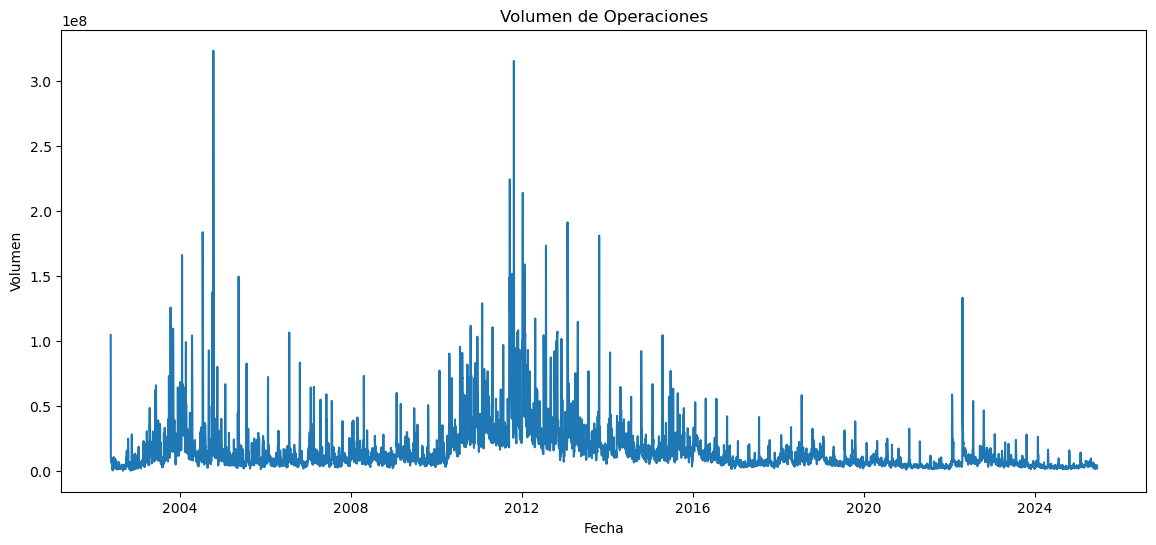

In [46]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['volume'])
plt.title('Volumen de Operaciones')
plt.xlabel('Fecha')
plt.ylabel('Volumen')
plt.show()

### Distribución de precio de cierre

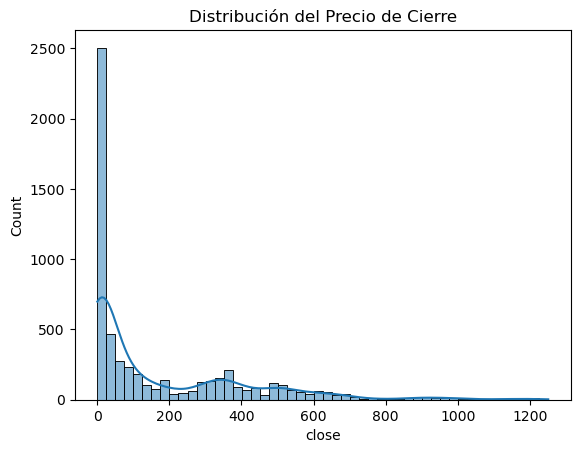

In [47]:
sns.histplot(df['close'], bins=50, kde=True)
plt.title('Distribución del Precio de Cierre')
plt.show()

## Indicadores financieros

In [48]:
# Calculo de media móvil de 30 días
df['MA30'] = df['close'].rolling(window=30).mean()

In [49]:
# Calculo de media móvil de 100 días
df['MA100'] = df['close'].rolling(window=100).mean()

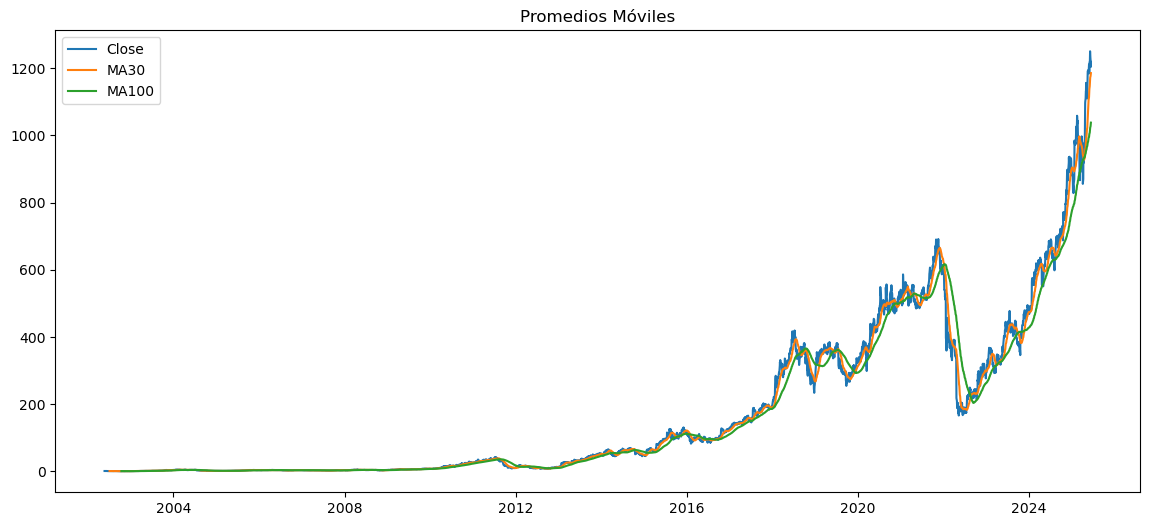

In [50]:
# Grafica de visualización
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['close'], label='Close')
plt.plot(df['date'], df['MA30'], label='MA30')
plt.plot(df['date'], df['MA100'], label='MA100')

plt.legend()
plt.title('Promedios Móviles')
plt.show()

## Análisis de volatibilidad

In [51]:
# Calculo del rendimiento diario
df['daily_return'] = df['close'].pct_change()

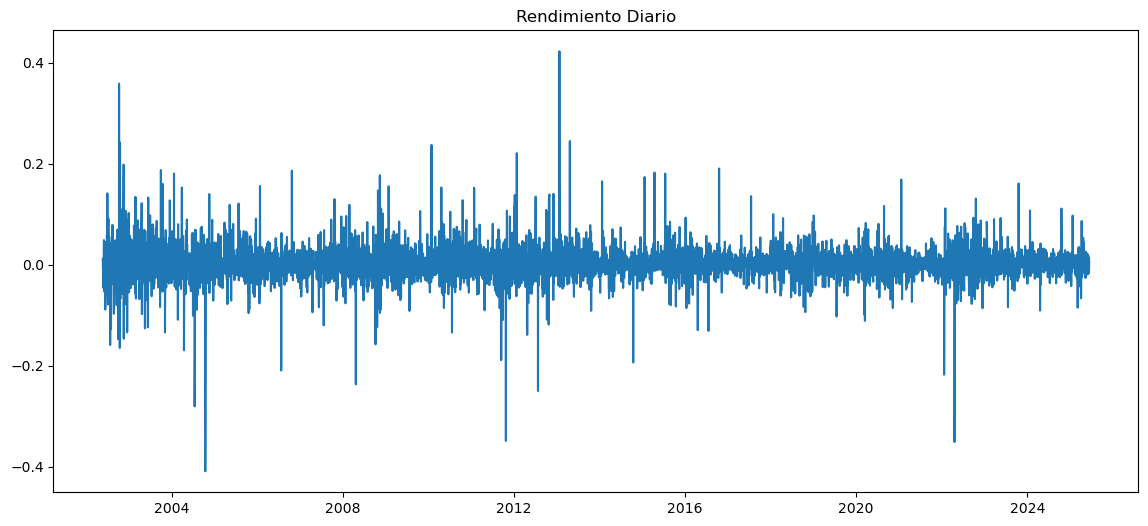

In [52]:
# Visualización
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['daily_return'])
plt.title('Rendimiento Diario')
plt.show()

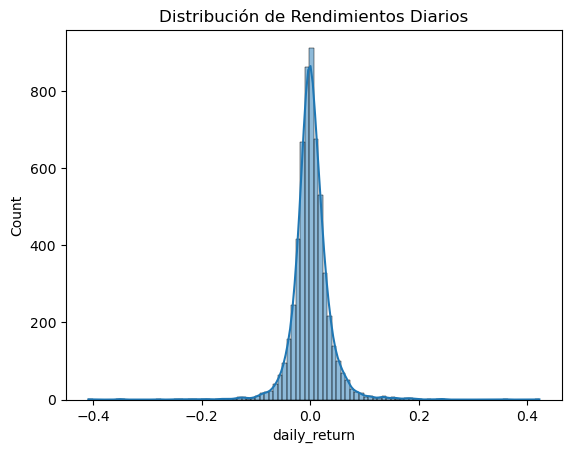

In [53]:
# Distribucion de rendimiento
sns.histplot(df['daily_return'].dropna(), bins=100, kde=True)
plt.title('Distribución de Rendimientos Diarios')
plt.show()

## Modelo predictivo

### Preparación de datos

In [54]:
# Variables
X = df[['open', 'high', 'low', 'volume']]
y = df['close']

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Entrenamiento del modelo

In [55]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Predicciones

In [56]:
y_pred = model.predict(X_test)

### Evaluaciones

In [58]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 1.143535739258035
RMSE: 2.5212481170884984


### Visualización

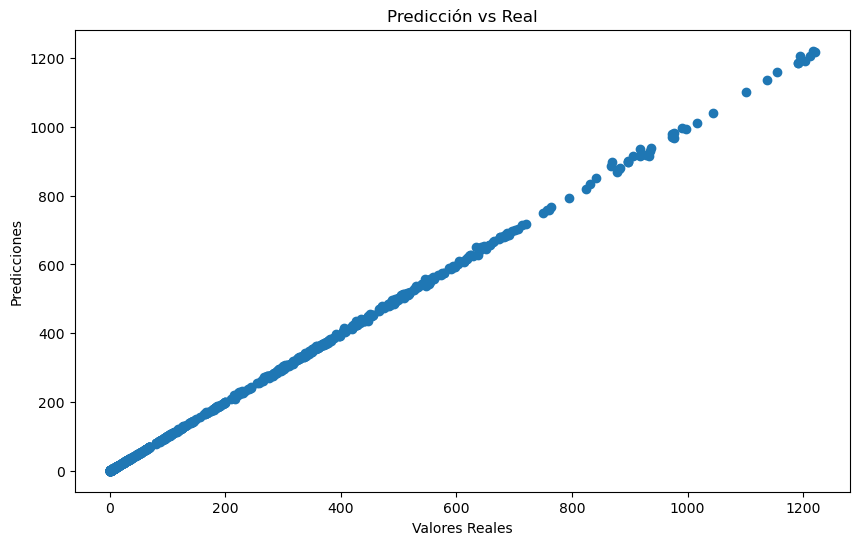

In [59]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicción vs Real')
plt.show()